In [11]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, Dataset
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Plate parameters
size = 2.0  # Length of the plate
t_max = 5.0  # Maximum time

# Hyperparameters
layers = [3, 50, 50, 1]
lr = 0.001
batch_size = 32
epochs = 100

lambda_data = 100.0
lambda_heat = 1.0
lambda_bc = 10.0

Using device: cuda


In [13]:
!wget https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian.csv

class CSVDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file).values.astype('float32')
        self.X = torch.tensor(self.data[:, 1:4])
        self.y = torch.tensor(self.data[:, 4:])

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CSVDataset('dual_gaussian.csv')
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

--2026-03-21 03:32:59--  https://raw.githubusercontent.com/brcktn/Inverse-Heat-PINN/main/training_data/dual_gaussian.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3662438 (3.5M) [text/plain]
Saving to: ‘dual_gaussian.csv.1’

dual_gaussian.csv.1 100%[===================>]   3.49M  --.-KB/s    in 0.02s   

2026-03-21 03:32:59 (180 MB/s) - ‘dual_gaussian.csv.1’ saved [3662438/3662438]



In [14]:
class HeatPINN(nn.Module):
    """
    A simple feedforward neural network
    """
    def __init__(self, layers):
        """
        Parameters
        ----------
        layers : list
            A list of integers specifying the number of neurons in each layer, including input and output layers.
        """
        super(HeatPINN, self).__init__()

        self.alpha = nn.Parameter(torch.tensor([0.1], dtype=torch.float32))  # Learnable thermal diffusivity

        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.layers.append(nn.Tanh())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


model = HeatPINN(layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [20]:
def sample_points(num_points, size, t_max):
    """
    Sample points uniformly from the domain [-L/2, L/2] x [-L/2, L/2] x [0, t_max]

    Parameters
    ----------
    num_points : int
        The number of points to sample.
    size : float
        The size of the spatial domain (length of the plate).
    t_max : float
        The maximum time to sample from.

    Returns
    -------
    torch.Tensor
        A tensor of shape (num_points, 3) containing the sampled points.
    """
    x = torch.rand(num_points, 1) * size - size / 2  # Sample x in [-L/2, L/2]
    y = torch.rand(num_points, 1) * size - size / 2  # Sample y in [-L/2, L/2]
    t = torch.rand(num_points, 1) * t_max  # Sample t in [0, t_max]

    x.requires_grad = True
    y.requires_grad = True
    t.requires_grad = True

    return torch.cat([x, y, t], dim=1)


def sample_boundary_points(num_points, size, t_max):
    """
    Uniformly samples points from the boundary of the plate
    over the full time interval.

    Parameters
    ----------
    num_points : int
        The number of points to sample.
    size : float
        The size of the spatial domain (length of the plate).
    t_max : float
        The maximum time to sample from.

    Returns
    -------
    torch.Tensor
        A tensor of shape (num_points, 3) containing the sampled boundary points.
    """
    points_per_edge = num_points // 4
    # left edge (x = -L/2)
    x_left = torch.full((points_per_edge, 1), -size / 2)
    y_left = torch.rand(points_per_edge, 1) * size - size / 2
    t_left = torch.rand(points_per_edge, 1) * t_max
    left_edge = torch.cat([x_left, y_left, t_left], dim=1)
    
    # right edge (x = L/2)
    x_right = torch.full((points_per_edge, 1), size / 2)
    y_right = torch.rand(points_per_edge, 1) * size - size / 2
    t_right = torch.rand(points_per_edge, 1) * t_max
    right_edge = torch.cat([x_right, y_right, t_right], dim=1)
    
    # top edge (y = -L/2)
    x_top = torch.rand(points_per_edge, 1) * size - size / 2
    y_top = torch.full((points_per_edge, 1), -size / 2)
    t_top = torch.rand(points_per_edge, 1) * t_max
    top_edge = torch.cat([x_top, y_top, t_top], dim=1)
    
    # bottom edge (y = L/2)
    x_bottom = torch.rand(points_per_edge, 1) * size - size / 2
    y_bottom = torch.full((points_per_edge, 1), size / 2)
    t_bottom = torch.rand(points_per_edge, 1) * t_max
    bottom_edge = torch.cat([x_bottom, y_bottom, t_bottom], dim=1)

    # Concatenate all boundary points
    boundary_points = torch.cat([left_edge, right_edge, top_edge, bottom_edge], dim=0)
    
    # requires_grad not needed because no dirivatives will be used
    return boundary_points

In [16]:
def data_loss(model, x_batch, y_batch):
    """
    Supervised loss on sampled dataset points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    x_batch : torch.Tensor
        A batch of input points (x, y, t).
    y_batch : torch.Tensor
        A batch of corresponding temperature values.
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss between the model predictions and the true values.
    """
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    pred = model(x_batch)
    return torch.mean((pred - y_batch) ** 2)


def physics_loss(model, points):
    """
    Physics loss enforcing the heat equation at sampled points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    points : torch.Tensor
        A batch of input points (x, y, t) where the physics loss is evaluated.
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss enforcing the heat equation at the given points.
    """
    points = points.to(device)
    pred = model(points)

    # Compute gradients for PDE residual
    grad = torch.autograd.grad(pred, points, grad_outputs=torch.ones_like(pred), create_graph=True)[0]
    u_t = grad[:, 2:3]  # Time derivative
    u_x = grad[:, 0:1]  # Spatial derivative in x
    u_y = grad[:, 1:2]  # Spatial derivative in y

    u_xx = torch.autograd.grad(u_x, points, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = torch.autograd.grad(u_y, points, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    alpha = model.alpha  # Learnable thermal diffusivity

    # Heat equation residual: u_t - alpha * (u_xx + u_yy) = 0
    residual = u_t - alpha * (u_xx + u_yy)
    
    return torch.mean(residual ** 2)


def boundary_loss(model, boundary_points):
    """
    Boundary loss enforcing the boundary conditions at sampled boundary points.

    Parameters
    ----------
    model : nn.Module
        The PINN model.
    boundary_points : torch.Tensor
        A batch of input points (x, y, t) on the boundary where the boundary loss is evaluated.
    
    Returns
    -------
    torch.Tensor
        The mean squared error loss enforcing the boundary conditions at the given points.
    """
    boundary_points = boundary_points.to(device)
    pred = model(boundary_points)

    # For this example, we assume Dirichlet boundary conditions with u = 0 on the boundary
    return torch.mean(pred ** 2)

In [ ]:
def train(model, dataloader, optimizer, epochs, lambda_data=1.0, lambda_heat=1.0, lambda_bc=1.0):
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        total_data_loss = 0.0
        total_physics_loss = 0.0
        total_boundary_loss = 0.0
        
        for x_batch, y_batch in dataloader:
            optimizer.zero_grad()

            # Sample points for physics and boundary losses
            physics_points = sample_points(batch_size, size, t_max)
            boundary_points = sample_boundary_points(batch_size, size, t_max)

            # Compute losses
            loss_data = data_loss(model, x_batch, y_batch)
            loss_physics = physics_loss(model, physics_points)
            loss_boundary = boundary_loss(model, boundary_points)

            # Total loss with weighting
            loss = lambda_data * loss_data + lambda_heat * loss_physics + lambda_bc * loss_boundary

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_data_loss += loss_data.item()
            total_physics_loss += loss_physics.item()
            total_boundary_loss += loss_boundary.item()
        
        avg_loss = total_loss / len(dataloader)
        avg_data_loss = total_data_loss / len(dataloader)
        avg_physics_loss = total_physics_loss / len(dataloader)
        avg_boundary_loss = total_boundary_loss / len(dataloader)
        
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}, Alpha: {model.alpha.item():.4f}, Data: {avg_data_loss:.6f}, Physics: {avg_physics_loss:.6f}, Boundary: {avg_boundary_loss:.6f}')

train(model, dataloader, optimizer, epochs, lambda_data, lambda_heat, lambda_bc)

Epoch 1/100, Loss: 0.239399, Data: 0.001725, Physics: 0.005880, Boundary: 0.006107, Alpha: 0.0619
Epoch 2/100, Loss: 0.061269, Data: 0.000377, Physics: 0.008507, Boundary: 0.001506, Alpha: 0.0307
Epoch 3/100, Loss: 0.036243, Data: 0.000214, Physics: 0.007519, Boundary: 0.000728, Alpha: 0.0072
Epoch 4/100, Loss: 0.022651, Data: 0.000118, Physics: 0.005762, Boundary: 0.000509, Alpha: 0.0093
Epoch 5/100, Loss: 0.016572, Data: 0.000079, Physics: 0.004491, Boundary: 0.000423, Alpha: 0.0043
Epoch 6/100, Loss: 0.011740, Data: 0.000050, Physics: 0.003340, Boundary: 0.000342, Alpha: 0.0012
Epoch 7/100, Loss: 0.009189, Data: 0.000038, Physics: 0.002614, Boundary: 0.000281, Alpha: 0.0042
Epoch 8/100, Loss: 0.006720, Data: 0.000024, Physics: 0.002092, Boundary: 0.000220, Alpha: 0.0015


KeyboardInterrupt: 

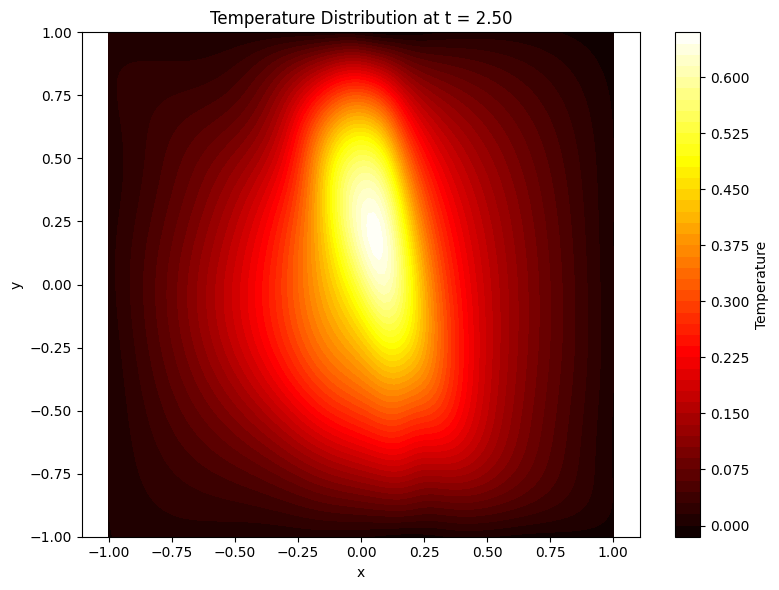

In [22]:
def plot_heatmap(model, t, size=2.0, resolution=100):
    """
    Plot a heatmap of the temperature distribution at a given time.
    
    Parameters
    ----------
    model : nn.Module
        The trained PINN model.
    t : float
        The time at which to plot the temperature distribution.
    size : float
        The size of the spatial domain (length of the plate).
    resolution : int
        The number of points in each spatial dimension for the grid.
    """
    model.eval()
    
    # Create a grid of (x, y) points
    x = torch.linspace(-size/2, size/2, resolution)
    y = torch.linspace(-size/2, size/2, resolution)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Flatten and create input tensor with constant time
    x_flat = X.flatten().unsqueeze(1)
    y_flat = Y.flatten().unsqueeze(1)
    t_tensor = torch.full_like(x_flat, t)
    
    points = torch.cat([x_flat, y_flat, t_tensor], dim=1).to(device)
    
    # Get predictions
    with torch.no_grad():
        u = model(points)
    
    # Reshape to grid
    U = u.reshape(resolution, resolution).cpu().numpy()
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(X.numpy(), Y.numpy(), U, levels=50, cmap='hot')
    plt.colorbar(label='Temperature')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Temperature Distribution at t = {t:.2f}')
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
    
    model.train()

plot_heatmap(model, t=2.5, size=size, resolution=100)